# Lab 16: Bagging and boosting comparison

Built-in breast-cancer data. Compares five models, training-only 5-fold CV and held-out test scores. Educational comparison, not clinical guidance.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


            Model  CV mean accuracy   CV std  Test accuracy  Test macro F1
    Decision tree          0.938960 0.021582       0.944056       0.939560
          Bagging          0.960109 0.009332       0.958042       0.954670
    Random forest          0.962462 0.017232       0.958042       0.954670
         AdaBoost          0.967114 0.018851       0.965035       0.962067
Gradient boosting          0.960137 0.018982       0.958042       0.954284


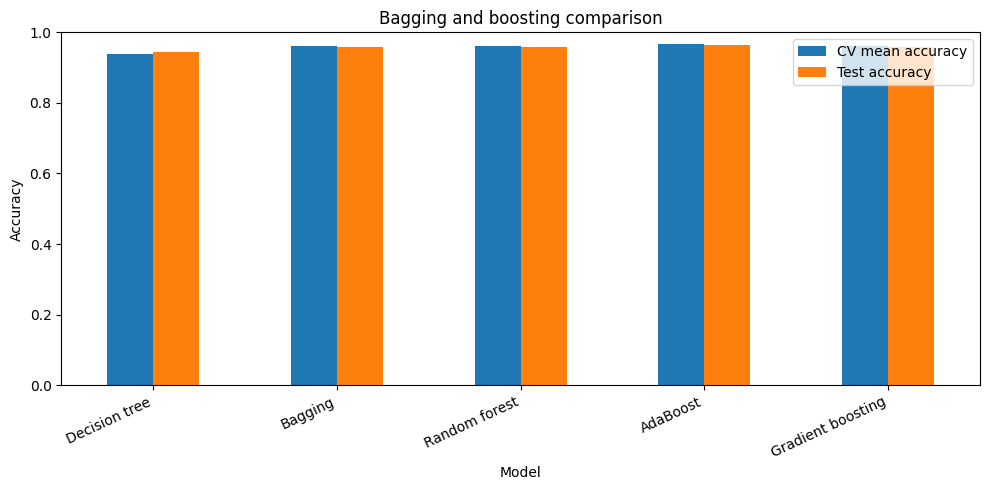

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.metrics import accuracy_score,f1_score
D=load_breast_cancer();X_train,X_test,y_train,y_test=train_test_split(D.data,D.target,test_size=.25,random_state=42,stratify=D.target)
models={'Decision tree':DecisionTreeClassifier(max_depth=3,random_state=42),'Bagging':BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3),n_estimators=50,random_state=42),'Random forest':RandomForestClassifier(n_estimators=100,random_state=42),'AdaBoost':AdaBoostClassifier(n_estimators=50,random_state=42),'Gradient boosting':GradientBoostingClassifier(random_state=42)}
rows=[];cv=StratifiedKFold(5,shuffle=True,random_state=42)
for name,model in models.items():
 scores=cross_val_score(model,X_train,y_train,cv=cv);model.fit(X_train,y_train);pred=model.predict(X_test);rows.append({'Model':name,'CV mean accuracy':scores.mean(),'CV std':scores.std(),'Test accuracy':accuracy_score(y_test,pred),'Test macro F1':f1_score(y_test,pred,average='macro')})
results=pd.DataFrame(rows);print(results.to_string(index=False));results.to_csv('model_comparison.csv',index=False)
results.set_index('Model')[['CV mean accuracy','Test accuracy']].plot.bar(figsize=(10,5),ylim=(0,1));plt.ylabel('Accuracy');plt.title('Bagging and boosting comparison');plt.xticks(rotation=25,ha='right');plt.tight_layout();plt.show()
